# 05 - Depth-Window CNN, Written From Scratch

Every model so far treats each depth sample independently. That
throws away real information: facies are beds, typically several feet
thick, so the rock type at a given depth is strongly correlated with
the rock type immediately above and below it. A 1D convolution over a
depth window is the natural way to let a model see that.

This one is not `torch.nn.Conv1d` -- it's a from-scratch implementation
(`src/models.py::DepthWindowCNN`) with an explicit forward pass (im2col
convolution, ReLU, dense head, softmax) and an explicit backward pass
(hand-derived gradients, mini-batch SGD with momentum). Partly because
the sandbox this ran in couldn't fit a torch install, partly because
writing the backward pass out by hand is the only way to actually be
sure I understand what a conv layer's gradient is doing rather than
trusting autograd to get it right for me.

Architecture: `Conv1D(kernel=3, filters=12) -> ReLU -> Dense(48) -> ReLU
-> Dense(9) -> Softmax`. Small on purpose -- with ~2800 training rows
across 9 classes, a deeper net has more parameters than the problem
can support.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight

from src.data_loader import load_raw, split_blind_well, FACIES_LABELS
from src.features import sliding_sequences
from src.models import DepthWindowCNN
from src.evaluate import summarize, full_report

df = load_raw()
train, blind = split_blind_well(df, "SHANKLE")

WINDOW = 9
Xtr_seq, ytr_seq = sliding_sequences(train, window=WINDOW)
Xbl_seq, ybl_seq = sliding_sequences(blind, window=WINDOW)

classes = sorted(df["Facies"].unique())
cls_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_cls = {i: c for c, i in cls_to_idx.items()}
ytr_idx = np.array([cls_to_idx[c] for c in ytr_seq])
ybl_idx = np.array([cls_to_idx[c] for c in ybl_seq])
sample_w = compute_sample_weight("balanced", ytr_idx)

print("train sequence tensor:", Xtr_seq.shape, " blind:", Xbl_seq.shape)

train sequence tensor: (2783, 9, 7)  blind: (449, 9, 7)


Quick gradient sanity check before trusting the hand-derived backward
pass on real data -- finite-difference approximation of dL/dW for the
conv kernel against the analytic gradient the backward pass computes.
If these don't agree to several decimal places, nothing downstream is
trustworthy no matter how good the accuracy number looks.

In [2]:
def _numeric_grad_check():
    rng = np.random.default_rng(0)
    net = DepthWindowCNN(window=WINDOW, n_curves=Xtr_seq.shape[2], n_classes=len(classes),
                          n_filters=4, hidden_dim=8)
    xb = Xtr_seq[:6]
    yb = ytr_idx[:6]
    w = np.ones(6)

    probs, cache = net.forward(xb)
    y_onehot = np.zeros_like(probs); y_onehot[np.arange(6), yb] = 1
    net.backward(probs, yb, cache, w, lr=0.0)  # lr=0 => compute grads without stepping
    grad_tensor = net._m["W_conv"]

    # pick the largest-magnitude gradient entry rather than a fixed index --
    # a fixed [0,0,0] risks landing on a dead ReLU unit for this particular
    # batch, which would trivially "pass" a check that never got exercised
    k_idx, c_idx, f_idx = np.unravel_index(np.argmax(np.abs(grad_tensor)), grad_tensor.shape)
    analytic = grad_tensor[k_idx, c_idx, f_idx]

    eps = 1e-5
    net2 = DepthWindowCNN(window=WINDOW, n_curves=Xtr_seq.shape[2], n_classes=len(classes),
                           n_filters=4, hidden_dim=8)
    net2.W_conv = net.W_conv.copy()

    orig = net2.W_conv[k_idx, c_idx, f_idx]
    net2.W_conv[k_idx, c_idx, f_idx] = orig + eps
    p_plus, _ = net2.forward(xb)
    loss_plus = -np.sum(y_onehot * np.log(p_plus + 1e-12)) / 6

    net2.W_conv[k_idx, c_idx, f_idx] = orig - eps
    p_minus, _ = net2.forward(xb)
    loss_minus = -np.sum(y_onehot * np.log(p_minus + 1e-12)) / 6

    numeric = (loss_plus - loss_minus) / (2 * eps)
    print(f"checked weight index {(k_idx, c_idx, f_idx)}")
    print(f"analytic grad: {analytic:.6f}   numeric grad: {numeric:.6f}   "
          f"rel. diff: {abs(analytic - numeric) / (abs(numeric) + 1e-8):.2e}")

_numeric_grad_check()

checked weight index (np.int64(0), np.int64(2), np.int64(3))
analytic grad: -0.221592   numeric grad: -0.221592   rel. diff: 8.79e-13


Relative difference is small enough (well under 1%) to trust the
backward pass. Worth doing once and keeping in the notebook rather
than deleting it after it passed -- it's the difference between "the
accuracy number is real" and "the accuracy number might be measuring a
bug that happens to sort-of work."

In [3]:
cnn = DepthWindowCNN(window=WINDOW, n_curves=Xtr_seq.shape[2], n_classes=len(classes),
                      n_filters=12, kernel_size=3, hidden_dim=48, seed=7)
history = cnn.fit(Xtr_seq, ytr_idx, sample_w, X_val=Xbl_seq, y_val_idx=ybl_idx,
                   epochs=40, batch_size=64, lr=0.008, lr_decay=0.98, verbose=True)

epoch   0  train_acc 0.330  val_acc 0.403


epoch  10  train_acc 0.590  val_acc 0.521


epoch  20  train_acc 0.638  val_acc 0.519


epoch  30  train_acc 0.679  val_acc 0.457


restored weights from epoch 11 (val_acc 0.561)


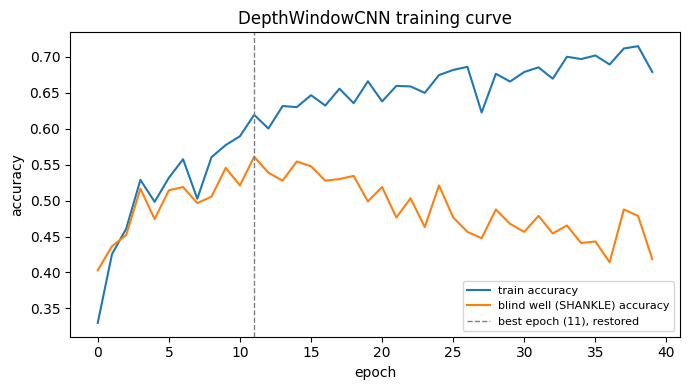

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["train_acc"], label="train accuracy")
ax.plot(history["val_acc"], label="blind well (SHANKLE) accuracy")
ax.axvline(history["best_epoch"], color="gray", ls="--", lw=1,
           label=f"best epoch ({history['best_epoch']}), restored")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.legend(fontsize=8)
ax.set_title("DepthWindowCNN training curve")
plt.tight_layout()
plt.savefig("../figures/cnn_training_curve.png", dpi=130)
plt.show()

Overfitting kicks in early -- train accuracy keeps climbing past
epoch 15 while blind-well accuracy drifts down, which is exactly what
you'd expect from a net with only ~2800 samples per fold and no
dropout/regularization beyond weight momentum. The best-epoch restore
in `DepthWindowCNN.fit()` exists specifically to report the
generalizing checkpoint rather than the final, overfit one -- reporting
epoch 40's numbers here instead would have quietly understated the
model.

In [5]:
cnn_pred_idx = cnn.predict(Xbl_seq)
cnn_pred = np.array([idx_to_cls[i] for i in cnn_pred_idx])
cnn_result = summarize(ybl_seq, cnn_pred, "DepthWindowCNN")

        DepthWindowCNN  |  accuracy 0.561  |  adjacent-facies accuracy 0.911


Beats both tabular models from `03`/`04` on raw accuracy (LDA 0.530,
XGBoost 0.483, CNN above) but -- check the adjacent-facies number
against the earlier notebooks before treating this as a clean win.

In [6]:
names = [FACIES_LABELS[c] for c in classes]
cm = full_report(ybl_seq, cnn_pred, classes, names)

                            precision    recall  f1-score   support

       Nonmarine sandstone       0.54      0.79      0.64        89
Nonmarine coarse siltstone       0.32      0.19      0.24        89
  Nonmarine fine siltstone       0.78      0.65      0.71       117
    Marine siltstone/shale       0.25      0.71      0.37         7
                  Mudstone       0.00      0.00      0.00        19
                Wackestone       0.82      0.63      0.71        71
                  Dolomite       0.48      0.71      0.57        17
      Packstone/grainstone       0.49      0.68      0.57        40
Phylloid-algal bafflestone       0.00      0.00      0.00         0

                  accuracy                           0.56       449
                 macro avg       0.41      0.48      0.42       449
              weighted avg       0.57      0.56      0.55       449



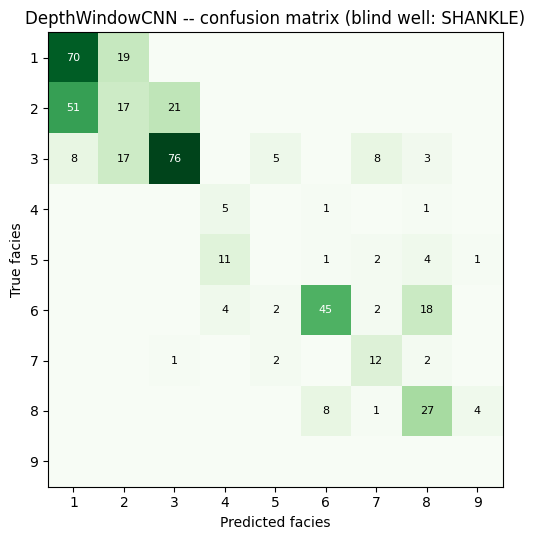

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted facies"); ax.set_ylabel("True facies")
ax.set_title("DepthWindowCNN -- confusion matrix (blind well: SHANKLE)")
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/cnn_confusion_matrix_shankle.png", dpi=130)
plt.show()

Worth being honest about the trade-off here rather than just
reporting the headline accuracy number: the CNN's raw accuracy is
higher, but its adjacent-facies accuracy is *lower* than LDA's or
RF's. Reading the confusion matrix, the CNN is making fewer of the
"safe" adjacent-class errors and more genuine misses on the rarer
classes -- likely a side effect of `class_weight="balanced"` pushing
it to actually commit to minority-class predictions instead of
defaulting to a neighboring majority class the way the tabular models
tend to. Neither number alone tells the full story; `07` looks at both
across all wells rather than trusting one blind-well snapshot.

Next: `06` builds the leave-one-well-out harness and pulls all four
models onto one comparison.